## Projeto de Regressão Múltipla: Análise do Consumo de Cerveja


Este notebook tem como objetivo construir e analisar um modelo de regressão linear múltipla para predizer o consumo de cerveja. Nosso foco será não apenas a construção do modelo, mas também a **validação das suposições do modelo** através de testes gráficos e estatísticos, seguindo as boas práticas da análise de regressão.

### Estrutura da Análise:

1.  **Preparação do Ambiente e Carregamento dos Dados**
2.  **Análise Exploratória dos Dados**
3.  **Análise de Correlação e Multicolinearidade**
4.  **Modelagem de Regressão Linear Múltipla**
5.  **Análise e Diagnóstico de Resíduos (Validação das Suposições do MQO)**
6.  **Interpretação Final do Modelo e Próximos Passos**

### 1. Preparação do Ambiente e Carregamento dos Dados

Importando bibliotecas

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd # Para manipulação e análise de dados em DataFrame
import numpy as np # Para operações numéricas e arrays
import matplotlib.pyplot as plt # Para criação de gráficos estáticos
import seaborn as sns # Para visualização de dados estatísticos (baseado no matplotlib)
import statsmodels.api as sm # Para modelos estatísticos, incluindo regressão linear (OLS)
from statsmodels.graphics.gofplots import qqplot # Para Q-Q plots (teste de normalidade)
from statsmodels.graphics.tsaplots import plot_acf # Para plotar a função de autocorrelação (ACF)
from statsmodels.stats.diagnostic import het_breuschpagan, het_white # Testes de homocedasticidade (Breusch-Pagan, White)
from statsmodels.stats.stattools import durbin_watson # Teste de Durbin-Watson (autocorrelação)
from statsmodels.stats.outliers_influence import variance_inflation_factor # Para VIF (multicolinearidade)
from scipy import stats # Para funções estatísticas, incluindo testes de normalidade (Shapiro-Wilk)

import warnings
warnings.filterwarnings("ignore") # Ignora avisos para uma saída mais limpa

Importando o data set

In [2]:
cerveja = pd.read_csv('Consumo_cerveja_1.csv')

### 2. Análise Exploratória dos Dados

Nesta seção, exploraremos as características básicas do nosso dataset, como dimensões, tipos de dados, valores ausentes e estatísticas descritivas. Uma boa compreensão dos dados é fundamental antes de qualquer modelagem.

#### Visualização das Primeiras Observações

Verificamos as 5 primeiras linhas do DataFrame para ter uma ideia da sua estrutura e conteúdo.

In [3]:
cerveja.head()

,Data,Temperatura_Media,Temperatura_Minima,Temperatura_Maxima,Precipitacao,Final_de_Semana,Consumo
0,01/01/2015,27.30,23.9,32.5,0.0,0,25.461
1,02/01/2015,27.02,24.5,33.5,0.0,0,28.972
2,03/01/2015,24.82,22.4,29.9,0.0,1,30.814
3,04/01/2015,23.98,21.5,28.6,1.2,1,29.799
4,05/01/2015,23.82,21.0,28.3,0.0,0,28.900


#### Visualização das Últimas Observações

In [4]:
cerveja.tail()

,Data,Temperatura_Media,Temperatura_Minima,Temperatura_Maxima,Precipitacao,Final_de_Semana,Consumo
360,27/12/2015,24.00,21.1,28.2,13.6,1,32.307
361,28/12/2015,22.64,21.1,26.7,0.0,0,26.095
362,29/12/2015,21.68,20.3,24.1,10.3,0,22.309
363,30/12/2015,21.38,19.3,22.4,6.3,0,20.467
364,31/12/2015,24.76,20.2,29.0,0.0,0,22.446


Dimensão da base de dados: são 365 observações e 7 variáveis.

In [5]:
cerveja.shape

(365, 7)

#### Verificação de Valores Ausentes (NULL)

Valores ausentes podem impactar a modelagem e precisam ser tratados. Verificamos a contagem de `NaN` em cada coluna.


In [6]:
print("Verificação de valores ausentes por coluna:")
print(cerveja.isnull().sum())

Verificação de valores ausentes por coluna:
Data                  0
Temperatura_Media     0
Temperatura_Minima    0
Temperatura_Maxima    0
Precipitacao          0
Final_de_Semana       0
Consumo               0
dtype: int64


#### Verificação dos Tipos das Variáveis

Confirmar os tipos de dados é crucial para garantir que as operações estatísticas e de modelagem sejam aplicadas corretamente.

In [7]:
print("Tipos de dados das variáveis:")
print(cerveja.dtypes)

Tipos de dados das variáveis:
Data                   object
Temperatura_Media     float64
Temperatura_Minima    float64
Temperatura_Maxima    float64
Precipitacao          float64
Final_de_Semana         int64
Consumo               float64
dtype: object


#### Análise Descritiva das Medidas de Tendência Central e Dispersão

Um sumário estatístico fornece medidas como média, desvio padrão, quartis, etc., para as variáveis numéricas.

In [8]:
print("Sumário estatístico das variáveis numéricas:")
cerveja.describe()

Sumário estatístico das variáveis numéricas:


,Temperatura_Media,Temperatura_Minima,Temperatura_Maxima,Precipitacao,Final_de_Semana,Consumo
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,21.226356,17.461370,26.611507,5.196712,0.284932,25.401367
std,3.180108,2.826185,4.317366,12.417844,0.452001,4.399143
min,12.900000,10.600000,14.500000,0.000000,0.000000,14.343000
25%,19.020000,15.300000,23.800000,0.000000,0.000000,22.008000
50%,21.380000,17.900000,26.900000,0.000000,0.000000,24.867000
75%,23.280000,19.600000,29.400000,3.200000,1.000000,28.631000
max,28.860000,24.500000,36.500000,94.800000,1.000000,37.937000


#### Análise Gráfica das Distribuições e Outliers

Histogramas e boxplots são essenciais para visualizar a distribuição de cada variável, identificar assimetrias, curtose e a presença de outliers. Outliers podem distorcer os resultados do modelo de regressão e, por isso, precisam ser avaliados e, se necessário, tratados. A variável `Data` não será plotada, pois é de tipo `object` e não numérica para esta análise.

Histogramas das variáveis numéricas:


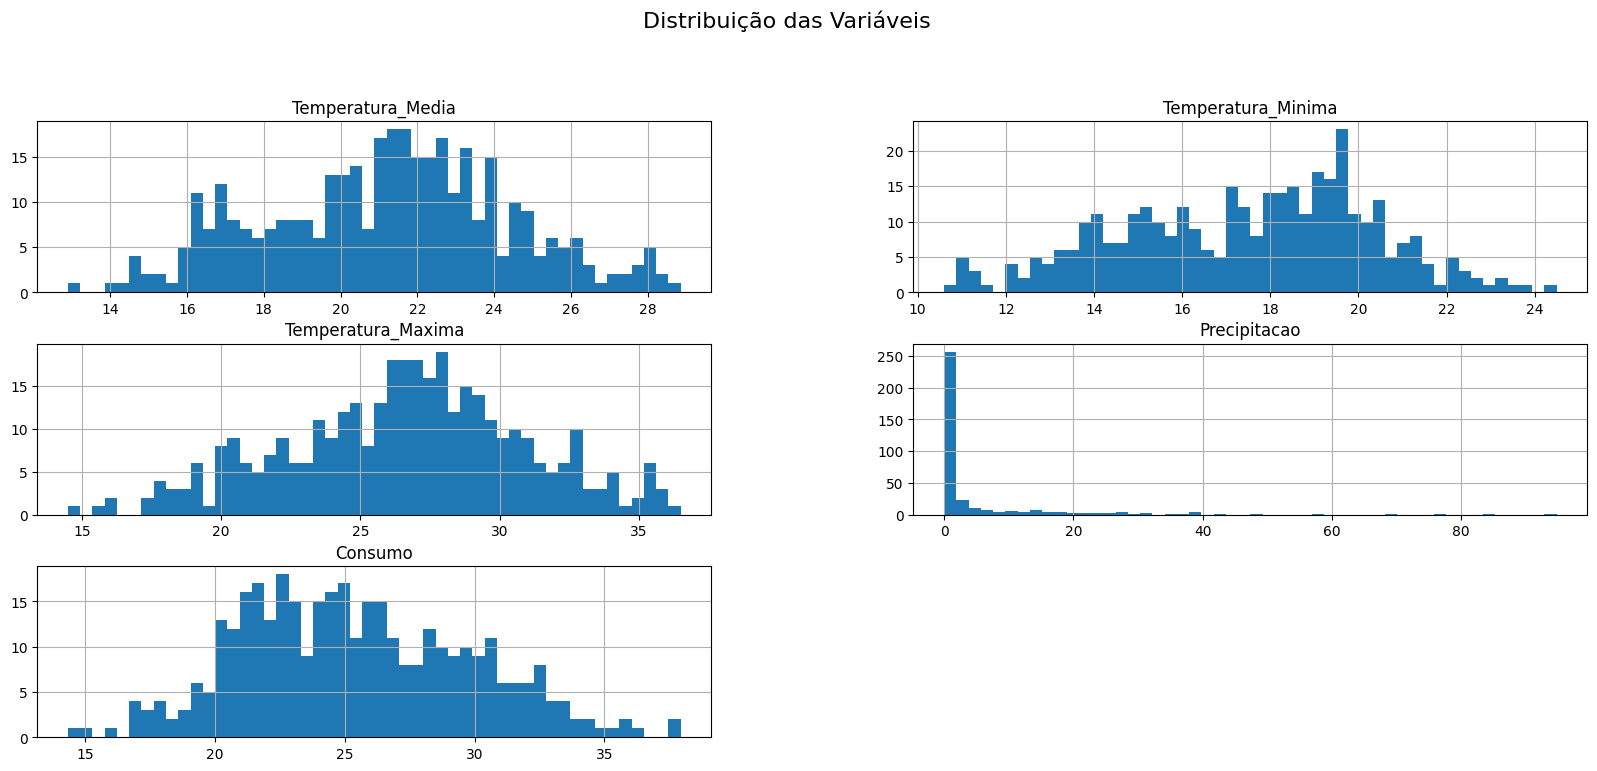

Boxplots das variáveis numéricas para identificação de outliers:


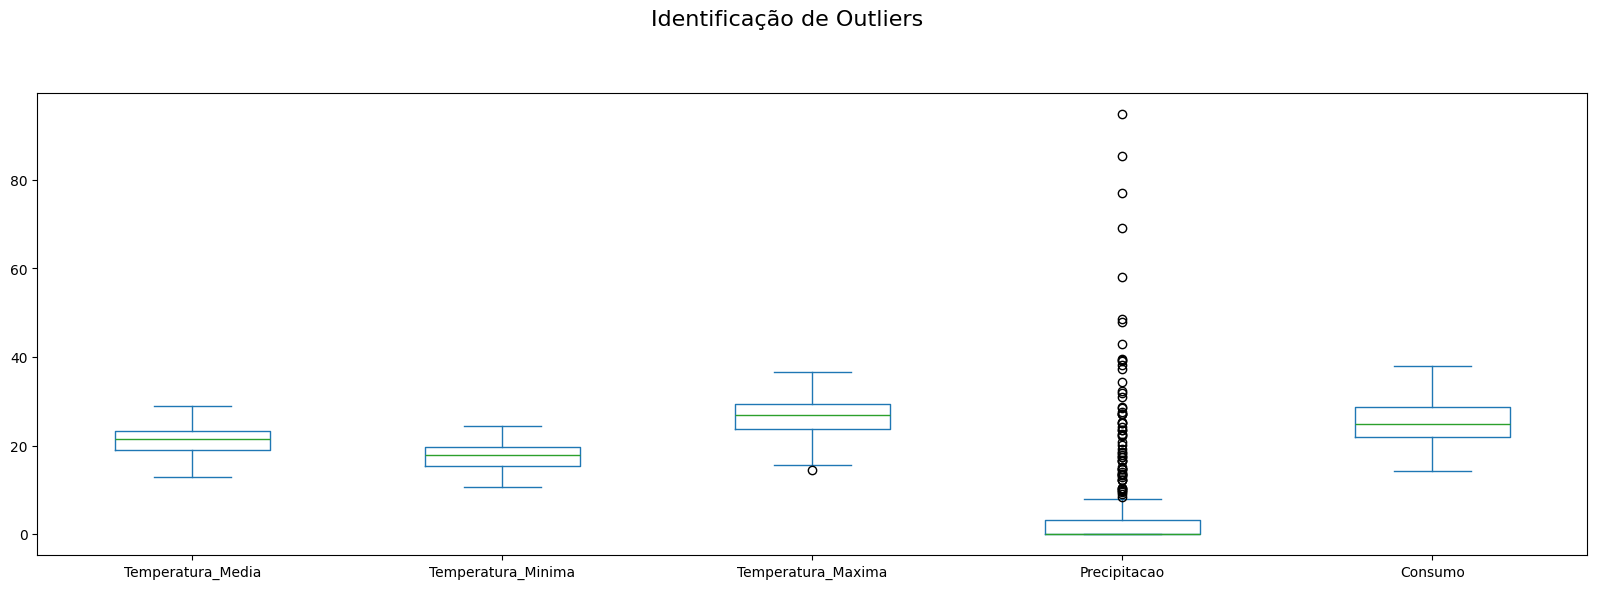

In [9]:
# Plotando histogramas para visualizar a distribuição das variáveis numéricas
print("Histogramas das variáveis numéricas:")
cerveja[['Temperatura_Media', 'Temperatura_Minima',
       'Temperatura_Maxima', 'Precipitacao',
       'Consumo']].hist(figsize=(20,8), bins=50);
plt.suptitle('Distribuição das Variáveis', y=1.02, fontsize=16)
plt.show()

# Plotando boxplots para identificar outliers
print("Boxplots das variáveis numéricas para identificação de outliers:")
cerveja[['Temperatura_Media', 'Temperatura_Minima',
       'Temperatura_Maxima', 'Precipitacao',
       'Consumo']].plot.box(figsize=(20,6));
plt.suptitle('Identificação de Outliers', y=1.02, fontsize=16)
plt.show()

Observações sobre a análise gráfica:
- As variáveis de temperatura (Média, Mínima, Máxima) e Consumo parecem ter distribuições razoavelmente simétricas, sem outliers extremos visíveis nos boxplots, embora 'Consumo' mostre alguns pontos além dos limites.
- A variável 'Precipitacao' apresenta uma distribuição altamente assimétrica à direita, com muitos zeros e vários outliers, indicando dias sem chuva e dias com chuva muito intensa. Isso pode exigir transformação de variável ou modelagem específica.
- 'Final_de_Semana' é uma variável binária (0 ou 1) e suas estatísticas e gráficos são interpretados de forma diferente, representando a proporção de dias de final de semana.

### 3. Análise de Correlação e Multicolinearidade

A análise de correlação quantifica a força e a direção da relação linear entre duas variáveis. A **multicolinearidade** ocorre quando as variáveis independentes em um modelo de regressão são altamente correlacionadas entre si, o que pode inflar a variância dos coeficientes do modelo, tornando-os menos estáveis e mais difíceis de interpretar. O **Fator de Inflação da Variância (VIF)** é uma métrica comumente usada para diagnosticar a multicolinearidade. Um VIF acima de 5 ou 10 geralmente indica um problema significativo.

--- Matriz de Correlação entre as variáveis --- 


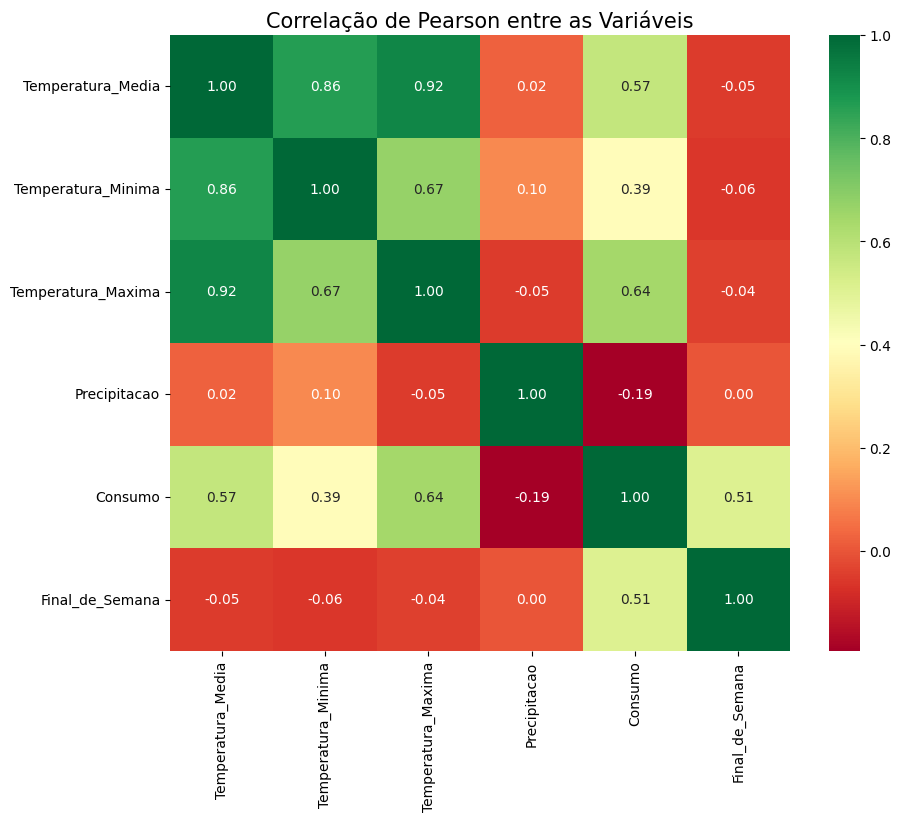

In [10]:
# Plotando um correlograma (heatmap da matriz de correlação)
print("--- Matriz de Correlação entre as variáveis --- ")
cerveja_quanti = cerveja[['Temperatura_Media', 'Temperatura_Minima',
       'Temperatura_Maxima', 'Precipitacao',
       'Consumo', 'Final_de_Semana']] 
plt.figure(figsize=(10,8))
sns.heatmap(cerveja_quanti.corr(),annot=True, cmap="RdYlGn", fmt=".2f");
plt.title('Correlação de Pearson entre as Variáveis',size=15);
plt.show()

Observações sobre a matriz de correlação:
- O consumo de cerveja tem uma forte correlação positiva com a Temperatura_Maxima (0.69) e com o fato de ser Final_de_Semana (0.51). Correlações moderadas são observadas com Temperatura_Media (0.47) e Temperatura_Minima (0.29).
- Uma correlação negativa fraca é observada com Precipitacao (-0.19), o que faz sentido (menos chuva = mais cerveja).
- Há uma alta correlação entre as variáveis de temperatura (Média, Mínima, Máxima), como esperado. Isso indica um potencial problema de multicolinearidade. Precisamos investigar isso com o VIF.

In [11]:
# Variáveis independentes para o cálculo do VIF (com a constante)
X = cerveja.drop(['Consumo','Data'],axis=1) # Removendo 'Data' e 'Consumo' para o VIF
X1 = sm.add_constant(X) # Adicionando a constante para o cálculo do VIF

In [12]:
print("\n--- Análise de Multicolinearidade (VIF) --- ")
# Criar um DataFrame para armazenar os VIFs
vif_data = pd.DataFrame()
vif_data["feature"] = X1.columns

# Calcular o VIF para cada variável
vif_data["VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]

print(vif_data)


--- Análise de Multicolinearidade (VIF) --- 
              feature        VIF
0               const  47.892879
1   Temperatura_Media  23.907247
2  Temperatura_Minima   6.506327
3  Temperatura_Maxima  11.286737
4        Precipitacao   1.038904
5     Final_de_Semana   1.003623


Interpretação dos Resultados do VIF:
- O VIF para 'Temperatura_Media', 'Temperatura_Minima' e 'Temperatura_Maxima' é  alto, o que confirma a forte multicolinearidade entre elas. Isso significa que essas variáveis estão explicando grande parte da mesma variação no modelo. Manter todas elas pode prejudicar a estabilidade e a interpretabilidade dos coeficientes.
- As variáveis 'Precipitacao' e 'Final_de_Semana' têm VIFs baixos (próximos de 1), indicando que não há multicolinearidade significativa entre elas e as outras variáveis.
Para resolver a multicolinearidade das temperaturas, optaremos por manter apenas a 'Temperatura_Maxima', que mostrou a maior correlação com o 'Consumo' na matriz de correlação.

### 4. Modelagem de Regressão Linear Múltipla

Com base na análise de correlação e multicolinearidade, vamos construir nosso modelo de regressão linear múltipla. A **Regressão Linear Múltipla** modela a relação entre uma variável dependente ($Y$) e duas ou mais variáveis independentes ($X_1, X_2, \dots, X_k$) usando a equação:

$Y = \\beta_0 + \\beta_1X_1 + \\beta_2X_2 + \\dots + \\beta_kX_k + \\epsilon$

Onde:
- $Y$ é a variável dependente (Consumo).
- $X_1, X_2, \\dots, X_k$ são as variáveis independentes.
- $\\beta_0$ é o intercepto (valor de $Y$ quando todas as $X_i$ são zero).
- $\\beta_i$ são os coeficientes de regressão (mudança esperada em $Y$ para cada unidade de mudança em $X_i$, mantendo as outras variáveis constantes).
- $\\epsilon$ é o termo de erro (resíduo).

O método de **Mínimos Quadrados Ordinários (MQO ou OLS)** será utilizado para estimar os coeficientes, buscando minimizar a soma dos quadrados dos resíduos.

In [13]:
# Definindo as variáveis independentes para o Modelo 1 (todas as originais, exceto 'Data')
X_modelo1 = cerveja.drop(['Consumo','Data'],axis=1)

# Definindo a variável dependente
y = cerveja['Consumo']

# Adicionando uma constante ao conjunto de variáveis independentes para o cálculo do intercepto (beta_0)
X_modelo1_const = sm.add_constant(X_modelo1)

# Ajustando o Modelo 1 de regressão linear usando OLS
modelo1 = sm.OLS(y, X_modelo1_const).fit()

print("--- Sumário do Modelo 1 (com todas as variáveis) ---")
modelo1.summary(title='Sumário do modelo 1')

--- Sumário do Modelo 1 (com todas as variáveis) ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                             Sumário do modelo 1                              
==============================================================================
Dep. Variable:                Consumo   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     187.1
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.19e-97
Time:                        17:22:17   Log-Likelihood:                -824.07
No. Observations:                 365   AIC:                             1660.
Df Residuals:                     359   BIC:                             1684.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  6.4447      0.845      7.627      0.000       4.783       8.107
Temperatura_Media      0.0308      0.188      0.164      0.870      -0.339       0.401
Temperatura_Minima    -0.0190      0.110     -0.172      0.863      -0.236       0.198
Temperatura_Maxima     0.6560      0.095      6.895      0.000       0.469       0.843
Precipitacao          -0.0575      0.010     -5.726      0.000      -0.077      -0.038
Final_de_Semana        5.1832      0.271     19.126      0.000       4.650       5.716
==============================================================================
Omnibus:                       39.362   Durbin-Watson:                   1.930
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.936
Skew:                           0.153   Prob(JB):                      0.00155
Kurtosis:                       2.130   Cond. No.                         271.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
# Definindo as variáveis independentes para o Modelo 2 (removendo as temperaturas com alta multicolinearidade e não significativas)
X_modelo2 = cerveja[['Temperatura_Maxima', 'Precipitacao', 'Final_de_Semana']]

# Adicionando a constante para o Modelo 2
X_modelo2_const = sm.add_constant(X_modelo2)

# Ajustando o Modelo 2 de regressão linear usando OLS
modelo2 = sm.OLS(y, X_modelo2_const).fit()

print("\\n--- Sumário do Modelo 2 (melhorado, sem multicolinearidade nas temperaturas) ---")
print(modelo2.summary(title='Sumário do modelo 2'))

\n--- Sumário do Modelo 2 (melhorado, sem multicolinearidade nas temperaturas) ---
                             Sumário do modelo 2                              
Dep. Variable:                Consumo   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.720
Method:                 Least Squares   F-statistic:                     313.5
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          3.85e-100
Time:                        17:22:17   Log-Likelihood:                -824.09
No. Observations:                 365   AIC:                             1656.
Df Residuals:                     361   BIC:                             1672.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

Os coeficientes e suas interpretações permanecem semelhantes, mas agora são mais confiáveis devido à ausência de multicolinearidade forte entre as preditoras selecionadas.
  - 'Temperatura_Maxima' (0.6685): Para cada aumento de 1 grau Celsius na temperatura máxima, o consumo de cerveja aumenta em aproximadamente 0.6685 litros, mantendo as outras variáveis constantes.
  - 'Precipitacao' (-0.0575): Para cada 1mm de aumento na precipitação, o consumo de cerveja diminui em aproximadamente 0.0575 litros.
  - 'Final_de_Semana' (5.1841): Em dias de final de semana, o consumo de cerveja é, em média, 5.1841 litros maior do que em dias de semana, mantendo as outras variáveis constantes.

**Conclusão do Modelo 2:** Este modelo é considerado melhor que o Modelo 1, pois é mais simples (menos variáveis) sem perder poder explicativo e com todas as variáveis preditoras sendo estatisticamente significativas. Ele é a base para a nossa validação das suposições.

### 5. Análise e Diagnóstico de Resíduos (Validação das Suposições do MQO)

A validação das suposições do modelo de regressão linear é crucial para garantir a validade e a confiabilidade das inferências estatísticas e das predições. As principais suposições do MQO são:

1.  **Linearidade da Relação:** A relação entre as variáveis dependente e independentes é linear.
2.  **Normalidade dos Resíduos:** Os termos de erro (resíduos) são normalmente distribuídos.
3.  **Homocedasticidade:** A variância dos resíduos é constante para todos os níveis das variáveis independentes.
4.  **Ausência de Autocorrelação:** Os resíduos são independentes uns dos outros.
5.  **Ausência de Multicolinearidade:** As variáveis independentes não são altamente correlacionadas entre si (já tratada na seção anterior com VIF).
6.  **Ausência de Outliers e Pontos de Alavancagem/Influência:** Não há observações que distorçam indevidamente o modelo.

In [15]:
residuos2 = modelo2.resid # Resíduos do Modelo 2
fitted_values2 = modelo2.fittedvalues # Valores ajustados (preditos) do Modelo 2

#### 5.1. Normalidade dos Resíduos

**Teoria:** A suposição de normalidade dos resíduos indica que os erros do modelo devem seguir uma distribuição normal. Isso é importante para a validade dos testes de hipóteses e intervalos de confiança dos coeficientes.

**Teste Gráfico (Q-Q Plot):** O Q-Q Plot compara os quantis dos resíduos com os quantis de uma distribuição normal teórica. Pontos alinhados à linha diagonal sugerem normalidade.

**Teste Estatístico (Shapiro-Wilk e Jarque-Bera):** Estes testes fornecem um p-valor para a hipótese nula de normalidade. Um p-valor > 0.05 sugere que não podemos rejeitar a hipótese de normalidade.

\n--- Teste de Normalidade dos Resíduos (Q-Q Plot) ---


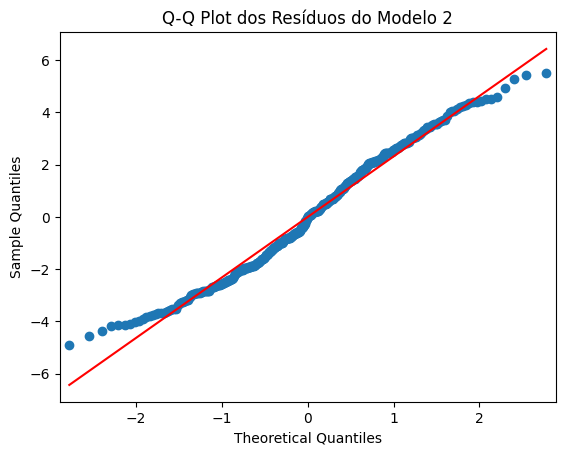

In [16]:
print("\\n--- Teste de Normalidade dos Resíduos (Q-Q Plot) ---")
fig = qqplot(residuos2, line='s') # line='s' adiciona uma linha de 45 graus para referência
plt.title("Q-Q Plot dos Resíduos do Modelo 2")
plt.show()

**Interpretação do Q-Q Plot:**
Os pontos no Q-Q plot estão razoavelmente alinhados com a linha diagonal, especialmente no centro da distribuição. Há pequenos desvios nas caudas, mas isso é comum e pode não ser um problema grave para amostras maiores.

**Teste de Shapiro-Wilk (Normalidade dos Resíduos)**
- H0 (Hipótese Nula): Os resíduos seguem uma distribuição normal.
- H1 (Hipótese Alternativa): Os resíduos NÃO seguem uma distribuição normal.

In [17]:
shapiro_test = stats.shapiro(residuos2)
print(f"Estatística de Shapiro-Wilk: {shapiro_test.statistic:.4f}")
print(f"P-valor: {shapiro_test.pvalue:.4f}")

if shapiro_test.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0. Os resíduos NÃO seguem uma distribuição normal. Isso pode indicar a necessidade de transformação da variável dependente ou de outras técnicas.")
else:
    print("Conclusão: Não rejeitamos H0. Os resíduos seguem uma distribuição normal. Esta suposição é razoavelmente atendida.")

Estatística de Shapiro-Wilk: 0.9800
P-valor: 0.0001
Conclusão: Rejeitamos H0. Os resíduos NÃO seguem uma distribuição normal. Isso pode indicar a necessidade de transformação da variável dependente ou de outras técnicas.


#### 5.2. Homocedasticidade (Variância Constante dos Resíduos)

**Teoria:** A homocedasticidade significa que a variância dos erros do modelo é constante para todos os níveis das variáveis independentes. A heterocedasticidade (variância não constante) pode levar a estimativas de coeficientes ineficientes e testes de hipóteses inválidos.

**Teste Gráfico (Resíduos vs. Valores Ajustados):** Este gráfico deve exibir uma dispersão aleatória e homogênea dos resíduos em torno da linha zero, sem padrões de funil ou cone.

**Testes Estatísticos (Breusch-Pagan e White):** Estes testes formais avaliam a hipótese nula de homocedasticidade. Um p-valor > 0.05 sugere homocedasticidade.

**Teste de Homocedasticidade (Resíduos vs. Valores Ajustados)**

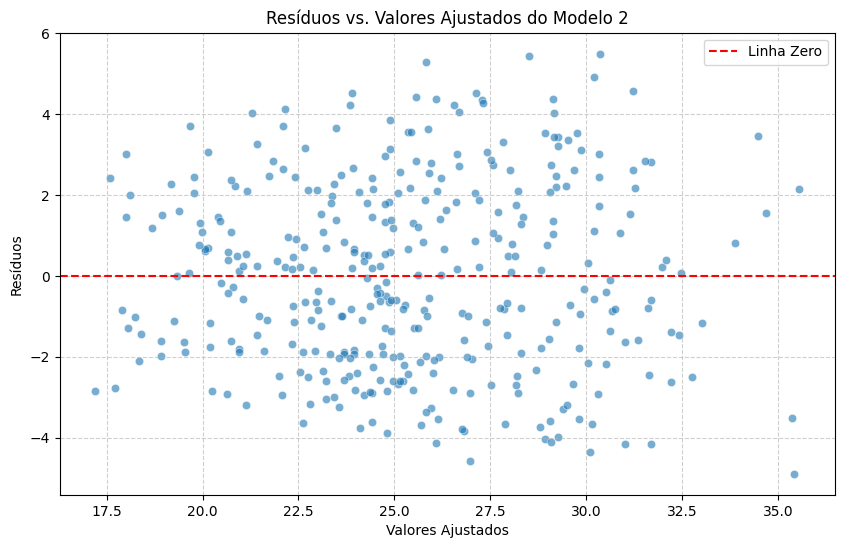

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values2, y=residuos2, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', label='Linha Zero')
plt.title('Resíduos vs. Valores Ajustados do Modelo 2')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Teste de Breusch-Pagan (Homocedasticidade)**
- H0 (Hipótese Nula): Homocedasticidade (a variância dos resíduos é constante).
- H1 (Hipótese Alternativa): Heterocedasticidade (a variância dos resíduos NÃO é constante).

In [19]:
breuschpagan_test = het_breuschpagan(residuos2, X_modelo2_const)
print(f"Estatística LM: {breuschpagan_test[0]:.4f}")
print(f"P-valor LM: {breuschpagan_test[1]:.4f}")
print(f"Estatística F: {breuschpagan_test[2]:.4f}")
print(f"P-valor F: {breuschpagan_test[3]:.4f}")

if breuschpagan_test[1] < 0.05:
    print("Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade. Isso pode afetar a eficiência das estimativas dos coeficientes.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade. A suposição é atendida.")

Estatística LM: 31.2234
P-valor LM: 0.0000
Estatística F: 11.2567
P-valor F: 0.0000
Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade. Isso pode afetar a eficiência das estimativas dos coeficientes.
